In [502]:
#| default_exp ECMs.state_estimators

In [503]:
#| hide
%load_ext autoreload
%autoreload 2

from typing import Any


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# State Estimators

These classes follow the same structure as ECMs, but use Bayesian Filtering to perform state estimation, assuming percept inputs are comming from an HMM, POMDP, or any kind of environment where the percept and environment state are not bijective. These state estimators assume that each dimension of a percept/sensory state takes one of a specified number of discrete values. The sample function returns a probability distribution over these values for each percept dimension/sensory category

First we define the core bayesian filtering mechanisms for an state estimator with a pre-defined HMM representing the environment.

In [504]:
#| export
import numpy as np
from numpy.typing import NDArray
from projective_simulation.ECMs.core import Abstract_ECM

class Bayesian_Filter(Abstract_ECM):
    """
    Bayesian Filter for recursive state estimation.

    Each state/hypothesis posits:
    1. A probability for all states of K sensory categories (with discrete state spaces).
    2. A probability that each state/hypothesis will be true when the sensory category states are next updated.

    The filter maintains a belief state over these hypotheses/states, assuming they are exhaustive and mutually exclusive.
    """
    def __init__(
        self,
        category_sizes: list[int],                                      #Number of states per sensory category.
        sensory_predictions: NDArray[np.float_],                        #Each row is a hypothesis; columns grouped by category_sizes, each group sums to 1.
        transition_predictions: NDArray[np.float_],                     #Each row is a hypothesis; columns give predicted probabilities for each hypothesis being true at the next step.
        belief_prior: NDArray[np.float_] = None,                 #Initial belief prior. If None, set to uniform.
        log_base: float=2.,                                             #Base for logarithms and exponentials.
        data_record: list[str] = [],                                    #List of internal variable names to record each time step. Accepts "all".
        record_until: int = -1                                          #Number of time steps to record. Default -1 disables recording.
    ):
        '''
        Defines self variables, sets up data recording, runs structure checks
        '''
        self.category_sizes = category_sizes
        self.category_indexer = np.repeat(np.arange(0, len(category_sizes)), category_sizes)
        self.num_hypotheses = np.shape(sensory_predictions)[0]
        self.transition_predictions = transition_predictions
        self.sensory_predictions = sensory_predictions
        self.log_base = log_base

        # --- State initialization ---
        self.percept = np.empty(len(self.category_sizes), dtype=int)
        self.likelihoods = np.zeros(self.num_hypotheses)
        self.belief_prior = np.full(self.num_hypotheses, 1/self.num_hypotheses) if belief_prior is None else belief_prior
        self.sensory_expectation = self.belief_prior @ self.sensory_predictions
        self.belief_posterior = np.full(self.num_hypotheses, 1/self.num_hypotheses)
        self.prepare_data_storage(data_record, record_until)

        self._check_structure()

    def _check_structure(self):
        if sum(self.category_sizes) != np.shape(self.sensory_predictions)[1]:
            raise ValueError("sensory_predictions must have a number of columns equal to the total number of percept category states")

        if np.shape(self.sensory_predictions)[0] != np.shape(self.transition_predictions)[0]:
            raise ValueError("sensory_predictions and transition_predictions must have the same number of rows")
        if np.shape(self.transition_predictions)[0] != np.shape(self.transition_predictions)[1]:
            raise ValueError("transition_predictions must be square")
        
        #~~Enforcement of probability distributions~~
        for k in range(len(self.category_sizes)):
            pred_sum = np.sum(self.sensory_expectation[self.category_indexer == k])
            if not np.abs(pred_sum - 1) < 1e-9:
                raise ValueError(
                    f"Predictions for each sensory category must be a probability distribution. "
                    f"category={k}"
                )
            for i in range(self.num_hypotheses):
                if not np.abs(np.sum(self.sensory_predictions[i, self.category_indexer == k]) - 1) < 1e-9:
                    raise ValueError("Each sensory category must sum to 1 in every hypothesis")
        if not np.abs(np.sum(self.belief_posterior) - 1) < 1e-9:
            raise ValueError("belief_posterior must sum to 1")
        if not np.abs(np.sum(self.belief_prior) - 1) < 1e-9:
            raise ValueError("belief_prior must sum to 1")
        if not (np.all(self.likelihoods >= 0) and np.all(self.likelihoods <= 1)):
            raise ValueError("likelihoods must be between 0 and 1")
        #~~End enforcement of probability distributions~~

        if self.record_until >= 0 and self.data_timer == self.record_until + 1:
            print("Warning: memory process exceeded steps pre-allocated for data-recording.")

    def prepare_data_storage(self, 
                             data_record: list[str], 
                             record_until: int):
        """Set up data recording structure for diagnostics and visualization."""
        self.data_dic: dict[str, None|NDArray[np.float_]] = {
            "belief_prior": None,
            "likelihoods": None,
            "belief_posterior": None,
            "sensory_expectation": None,
            "surprise": None
        }
        self.data_timer = 0
        self.record_until = record_until

        if "all" in data_record:
            if len(data_record) > 1:
                print("Warning: 'all' in data_record; additional entries ignored")
            data_record = list(self.data_dic.keys())

        if self.record_until < 0 and len(data_record) > 0:
            print("Warning: data_record set but record_until < 0; no data will be recorded")

        for variable in data_record:
            if variable not in self.data_dic:
                print(f"Warning: {variable} not a valid variable name; ignored")
            elif variable in ["belief_prior", "likelihoods", "belief_posterior"]:
                self.data_dic[variable] = np.full((self.record_until, self.num_hypotheses), -1., dtype=float)
            elif variable == "sensory_expectation":
                self.data_dic[variable] = np.full((self.record_until, np.sum(self.category_sizes)), -1., dtype=float)
            elif variable == "surprise":
                self.data_dic[variable] = np.full((self.record_until, len(self.category_sizes)), -1., dtype=float)

    def sample(self, 
               percept:NDArray[np.int_]   #Must be same length as self.category sizes.
               ) -> NDArray[np.float_]:   #Return sensory expectations
        """
        Given a percept, update belief and return a vector of sensory expectations.
        """
        self._check_structure()
        assert isinstance(percept, np.ndarray)
        assert np.issubdtype(percept.dtype, np.integer)
        if self.data_timer < self.record_until and self.data_dic["belief_prior"] is not None:
            self.data_dic["belief_prior"][self.data_timer, :] = self.belief_prior
        if self.data_timer < self.record_until and self.data_dic["sensory_expectation"] is not None:
            self.data_dic["sensory_expectation"][self.data_timer, :] = self.sensory_expectation

        self.percept = percept
        self.update_likelihoods(percept)
        if self.data_timer < self.record_until and self.data_dic["likelihoods"] is not None:
            self.data_dic["likelihoods"][self.data_timer, :] = self.likelihoods

        if self.data_timer < self.record_until and self.data_dic["surprise"] is not None:
            self.data_dic["surprise"][self.data_timer, :] = self.get_surprise()

        self.update_belief_posterior()
        if self.data_timer < self.record_until and self.data_dic["belief_posterior"] is not None:
            self.data_dic["belief_posterior"][self.data_timer, :] = self.belief_posterior
        
        self.learn(percept) # Placeholder for learning step in child classes

        self.update_priors()

        self.data_timer += 1
        return self.sensory_expectation

    def update_likelihoods(self, 
                           percept: np.ndarray[tuple[int],np.dtype[np.int_]]   #Must be same length as self.category sizes.
                           ):
        """Update the likelihoods for each hypothesis/state given the new percept."""
        if percept.shape[0] != len(self.category_sizes):
            raise ValueError(f'Percept vector size of {percept.shape[0]} does not match the number of perceptual categories, {len(self.category_sizes)}.')
        for i in range(len(self.category_sizes)):
            if percept[i] not in range(self.category_sizes[i]):
                raise ValueError("Percept state out of range for category.")
        one_hot_percept = self.get_one_hot_percept(percept) # boolean mask for current percept's one-hot encoding
        category_likelihoods = self.sensory_predictions[:, one_hot_percept] # shape (num_hypotheses, num_categories)
        self.likelihoods = np.prod(category_likelihoods, axis=1) # shape (num_hypotheses,)

    def update_belief_posterior(self):
        """Update the posterior belief over hypotheses."""
        unnormalized_posterior = self.likelihoods * self.belief_prior # element-wise product
        normalization_constant = np.sum(unnormalized_posterior)
        if np.sum(unnormalized_posterior) != 0:
            self.belief_posterior = unnormalized_posterior / normalization_constant
        else:
            print("Warning: unnormalized posterior probabilities sum to 0. Model may be invalid.")
            self.belief_posterior = np.zeros(self.num_hypotheses)
        
    def learn(self, percept:np.ndarray[tuple[int],np.dtype[np.int_]]  #Must be same length as self.category sizes
              ):
        """  
        Placeholder for learning step in child classes.
        """
        pass

    def update_priors(self):
        """Update the prior belief and sensory expectation for the next step."""
        self.update_belief_prior()
        self.sensory_expectation = self.belief_prior @ self.sensory_predictions # sum of sensory state probabilities weighted across states/hypotheses by prior belief

    def update_belief_prior(self):
        """Update the prior belief using the transition predictions and posterior."""
        row_sums = self.transition_predictions.sum(axis=1, keepdims=True)
        assert np.all(np.abs(row_sums - 1) < 1e-9), "Each row of transition_predictions must sum to 1"
        self.belief_prior = self.belief_posterior @ self.transition_predictions #sum of transition probabilities weighted across states/hypotheses by posterior belief

    def get_surprise(self) -> NDArray[np.float_]:
        """Compute the total surprise of the network. 0 likelihood observations (inf surprise) return -1."""
        category_likelihoods = self.sensory_expectation[self.get_one_hot_percept(percept=self.percept)]
        mask = category_likelihoods == 0. # avoids log(0)
        surprise_values = np.full(category_likelihoods.shape, -1.)
        surprise_values[~mask] = -np.log(category_likelihoods[~mask]) / np.log(self.log_base)
        return surprise_values

    def get_one_hot_percept(self, 
                            percept: NDArray[np.int_] | None
                            ) -> NDArray[np.bool_]:
        """Return a boolean mask for the current percept's one-hot encoding."""
        if percept is None:
            percept = self.percept
        one_hot_percept = np.zeros(np.sum(self.category_sizes), dtype=bool)
        one_hot_percept[np.cumsum(self.category_sizes) - self.category_sizes + self.percept] = True
        return one_hot_percept
        


### Bayesian_Filter Example
Here we provide a simple example of a Bayesian Filter for an environment in a deterministic cycles. This environment produces the percept sequence "green" "off" "blue" "off", then repeats.

In [505]:
from projective_simulation.envs.POMDPs import Cyclic_Env
from projective_simulation.methods.visualization import plot_heatmap


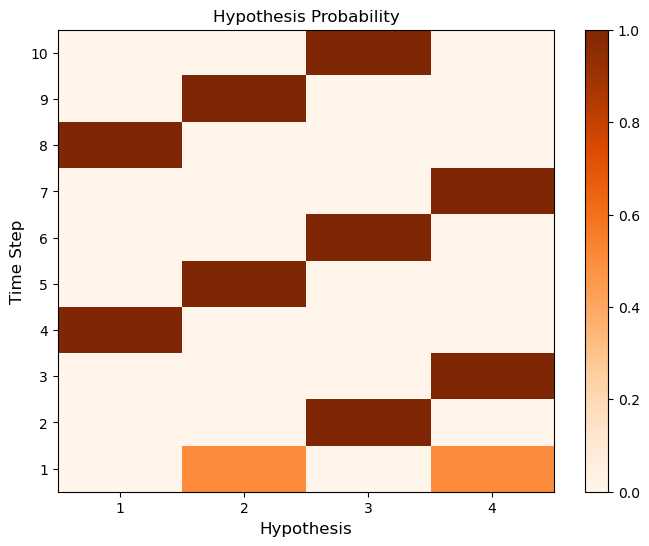

In [506]:
np.random.seed(1034300925)
#define percepts
off = 0
green = 1
blue = 2
colormap = np.array(['lightgrey', 'green', 'blue']) #for plotting

#define environment
percept_cycle = np.array([green,off,blue,off]) #light off, light green, light off, light blue
simple_light_cycle = Cyclic_Env(percept_cycle, initial_state = 1) #start with light off to get aliasing


#define agent
category_sizes = [3]
sensory_predictions = simple_light_cycle.observation_function
transition_predictions = simple_light_cycle.transition_function[:,:,0] #Removes action dimension added by environment constructor
test_bayesian_filter = Bayesian_Filter(category_sizes = category_sizes,
                                       sensory_predictions = sensory_predictions,
                                       transition_predictions = transition_predictions
                                      )

#prepare simulation
T = 10 #total time to run simulation
test_bayesian_filter.prepare_data_storage(data_record = ["all"], record_until = T)

#simulate
for t in range(T): #state in light of state to create initial aliasing
    percept = simple_light_cycle.get_observation()
    test_bayesian_filter.sample(percept)
    simple_light_cycle.transition(0) #use action 0

#plot memory trace activations over time
plot_heatmap(test_bayesian_filter.data_dic["belief_posterior"], title = "Hypothesis Probability", color = "Oranges", xlabel = "Hypothesis") # type: ignore

## Memory-Based State Estimators

In [507]:
#| export
#| hide

#### Sequence Memory Constructor Methods
import numpy as np
def Initialize_Memory_Based_Transition_Matrix(
        memory_capacity: int,                     #the number of memory-based hypothesis
        memory_bias: float,                       #parameter that defines initial edge-weights between stationary hypotheses and memory hypotheses. Exact implementation depends on stationary_transition_method
        num_hypotheses: int,                      #total number of hypoetheses (memory based + stationary/schematic)
        capacity_overflow_method: str,            #how to hnadle last memory based hypothesis. Accepts "stop encoding" or "loop"            
        stationary_transition_method: str ="first" #implementation of memory_bias. treats as values except "learned" as "first"
    )->NDArray[np.float_]:
    """
    Initializes a default transition matrix for a memory-based ECM with a given memory capacity and memory bias.
    """
    transition_predictions = np.zeros((num_hypotheses, num_hypotheses))
    # Fill the shifted diagonal for memory hypotheses (i.e., each i transitions to i+1, last to first)
    for i in range(memory_capacity-1):
        transition_predictions[i, (i + 1) % memory_capacity] = 1.0


    for i in range(memory_capacity, num_hypotheses):
        transition_predictions[i, i] = 1 - memory_bias
        transition_predictions[i, 0] = memory_bias
        transition_predictions[memory_capacity - 1, i] = 1 / (num_hypotheses - memory_capacity)

    return transition_predictions

In [508]:
#| export
#| hide

#### Sequence Memory Constructor Methods Cont.
def Initialize_Sensory_Predictions(
        category_sizes: list[int] | NDArray[np.int_],
        stationary_expectations: NDArray[np.float_],
        num_hypotheses: int
    )->NDArray[np.float_]:
    """
    Initializes a sensory prediction matrix for a memory-based ECM with a given category sizes and number of hypotheses.
    """
    if stationary_expectations is None:
        #set stationary expectations to uniform in all sensors
        print("No stationary_expectations given, using uniform distributions for all sensors")
        stationary_expectations = np.concatenate([
            np.full(category_size, 1 / category_size) for category_size in category_sizes
                ])
    sensory_predictions = np.tile(stationary_expectations, (num_hypotheses, 1))

    return sensory_predictions

In [509]:
#| export
import numpy as np
from projective_simulation.methods.visualization import plot_heatmap

class Sequence_Memory(Bayesian_Filter):
    """
    Memory-based Bayesian filter that encodes a sequence of percepts as memory traces.
    Each memory trace is a hypothesis about the environment, and the agent can transition between non-memory and memory hypotheses. 
    Memory traces are encoded by dynamic modification of transition function and observation function.
    """
    def __init__(
        self,
        category_sizes: list[int],                                                       #Number of states for each sensor/percept category.
        memory_capacity: int,                                                            #Number of memory-based hypotheses.
        memory_bias: float,                                                              #Probability of transitioning from non-memory to memory hypothesis space.
        stationary_expectations: NDArray[np.float_] = None,                              #Expectation of sensory states in stationarity. Default to uniform distributions for each sensor.
        sensory_predictions: NDArray[np.float_] = None,                                  #Sensory hypotheses matrix. If None, initialized to uniform.
        belief_prior: NDArray[np.float_] = None,                                         #Initial belief priors. If None, all prior on non-memory hypothesis.
        transition_predictions: NDArray[np.float_] = None,                               #Hypothesis transition matrix.
        next_trace: int = 0,                                                             #Starting memory index. 0 means no memory traces encoded yet.
        capacity_overflow_method: str="stop encoding",                                   #'loop' or 'stop encoding'.
        data_record: list[str] = [],                                                     #List of variable names to log each time step. Accepts "all".
        record_until: int = -1,                                                          #Number of steps to prepare for data logging. Negative disables recording.
        stationary_transition_method:str="first"                                         #'encoded', 'first', or 'learned'.
    ):
        """
        Initializes default sensory_predictions (observation function) and transition_predictions (transition function) if not given
        Runs structure checks
        """
        self.memory_capacity = memory_capacity
        self.memory_bias = memory_bias
        self.capacity_overflow_method = capacity_overflow_method
        self.num_non_memory_hypotheses = 1 #hard-coded for now to represent single stationary hypothesis, but flexbility exists to handle multiple non-memory hypotheses
        self.next_trace = next_trace
        self.effective_capacity = min(self.next_trace, self.memory_capacity)
        self.stationary_transition_method = stationary_transition_method

        num_hypotheses = self.num_non_memory_hypotheses + self.memory_capacity
        #default to uniform sensory predictions if not provided
        if sensory_predictions is None:
            sensory_predictions = Initialize_Sensory_Predictions(
                category_sizes=category_sizes,
                stationary_expectations=stationary_expectations,
                num_hypotheses=num_hypotheses
            )
        else:
            if not stationary_expectations is None:
                print("Warning: Provided sensory_predictions will overide stationary_expectations")

        #default to transition matrix that encodes sequence memory if not provided
        if transition_predictions is None:
            transition_predictions = Initialize_Memory_Based_Transition_Matrix(
                memory_capacity=self.memory_capacity,
                memory_bias=self.memory_bias,
                num_hypotheses=num_hypotheses,
                capacity_overflow_method=self.capacity_overflow_method,
                stationary_transition_method=stationary_transition_method
            )
        
        super().__init__(
            sensory_predictions=sensory_predictions,
            transition_predictions=transition_predictions,
            category_sizes=category_sizes,
            belief_prior=belief_prior,
            data_record=data_record,
            record_until=record_until
        )

        if belief_prior is None:
            self.belief_prior = np.zeros(self.num_hypotheses)
            self.belief_prior[self.memory_capacity:] = 1 / self.num_non_memory_hypotheses
        
        #overide placeholder belief posterior initialization from parent class to meet new requirements
        self.belief_posterior = np.zeros(self.num_hypotheses)
        self.belief_posterior[self.memory_capacity:] = 1 / self.num_non_memory_hypotheses 

        self._check_memory_structure()

    def _check_memory_structure(self):
        """
        Check that all internal probability distributions are valid (Per Parent class).
        Check that no belief is assigned to unencoded memory slots.
        """
        super()._check_structure()
        if self.effective_capacity < self.memory_capacity:
            if np.sum(self.belief_prior[self.effective_capacity:self.memory_capacity]) > 1e-9:
                raise ValueError("Prior belief assigned to unencoded memory slot.")
            if np.sum(self.belief_posterior[self.effective_capacity:self.memory_capacity]) > 1e-9:
                raise ValueError("Posterior belief assigned to unencoded memory slot.")
    
    def learn(self, 
              percept:NDArray[np.int_]|None  = None
              ):
        """
        Encode the current percept into memory by updating the sensory and transition predictions.
        """
        if percept is None:
            percept = self.percept
        if self.effective_capacity < self.memory_capacity or not self.capacity_overflow_method == "stop encoding":
            # if last memory slot filled and looping, update transition matrix to loop and decouple non-memory hypotheses
            self.encode_memory()
        self._check_memory_structure()

    def encode_memory(self, 
                      percept:NDArray[np.int_]|None = None):
        """
        Encode the current percept into memory by updating the sensory and transition predictions.
        """
        if self.effective_capacity < self.memory_capacity:
            self.effective_capacity += 1

        if percept is None:
            percept = self.percept    

        categorical_encoding = self.get_one_hot_percept(percept).astype(float)
        #overwrite memory trace with new encoding
        self.sensory_predictions[self.next_trace, :] = categorical_encoding

        if self.capacity_overflow_method == "stop encoding":
            #for other overflow methods, updating the next trace must be handled by the encode_memory method of the child class that introduces that method
            self.next_trace = (self.next_trace + 1) % self.memory_capacity

    def show_sensory_predictions(self, start_hypothesis =None, stop_hypothesis=None, **kwargs):
        """visualize sensory predictions as a heatmap"""
        if start_hypothesis is None:
            start_hypothesis = 1
        if stop_hypothesis is None:
            stop_hypothesis = self.num_hypotheses
        ticks = np.linspace(start_hypothesis, stop_hypothesis, num=min(stop_hypothesis, 5), dtype=int)
        default_yticks = ticks - 0.5
        default_ytick_labels = [f"$h_{{{i}}}$" for i in ticks]
        if stop_hypothesis == self.num_hypotheses:
            default_ytick_labels[-1] = "$h_*$"
        default_args = dict(
            title = "Sensory Predictions",
            xlabel = "Perceptual State (by category)",
            ylabel = "Hypothesis",
            yticks = default_yticks,
            ytick_labels = default_ytick_labels,
            xtick_labels = np.concatenate([range(cat_size) for cat_size in self.category_sizes]),
            color = "Greens",
            vmin = 0.,
            vmax = 1.,
            category_sizes = self.category_sizes,
            colorbar_kwargs={"label": "P(state|hypothesis)"}
        )
        default_args.update(kwargs)
        plot_heatmap(
            self.sensory_predictions[start_hypothesis-1:stop_hypothesis, :],
            **default_args
        )

    def show_transition_predictions(self, start_hypothesis =None, stop_hypothesis=None, **kwargs):
        """visualize transition predictions as a heatmap"""
        if start_hypothesis is None:
            start_hypothesis = 1
        if stop_hypothesis is None:
            stop_hypothesis = self.num_hypotheses
        ticks = np.linspace(start_hypothesis, stop_hypothesis, num=min(stop_hypothesis, 5), dtype=int)
        default_ticks = ticks - 0.5
        default_tick_labels = [f"$h_{{{i}}}$" for i in ticks]
        if stop_hypothesis == self.num_hypotheses:
            default_tick_labels[-1] = "$h_*$"
        default_args = dict(
            title = "Transition Predictions",
            xlabel = "Hypothesis",
            ylabel = "Hypothesis",
            yticks = default_ticks,
            ytick_labels = default_tick_labels,
            xticks = default_ticks,
            xtick_labels = default_tick_labels,
            color = "Blues",
            vmin = 0.,
            vmax = 1.,
            colorbar_kwargs={"label": "$P(h^{t+1}|h^t)$"}
        )
        default_args.update(kwargs)
        plot_heatmap(
            self.transition_predictions[start_hypothesis-1:stop_hypothesis, start_hypothesis-1:stop_hypothesis],
            **default_args
        )

### Sequence_Memory Example

In this example, set up a cyclical Hidden Markov Process in which a light turns green, turns off, turns blue, turns off, then turns green again and restarts. We show how to pass the percepts from this environment to the Memory Network, record the network's internal states over time, and visualize these states after simuluation.

In [510]:
from projective_simulation.envs.POMDPs import Cyclic_Env
from projective_simulation.methods.visualization import plot_heatmap, memory_filter_performance

No stationary_expectations given, using uniform distributions for all sensors


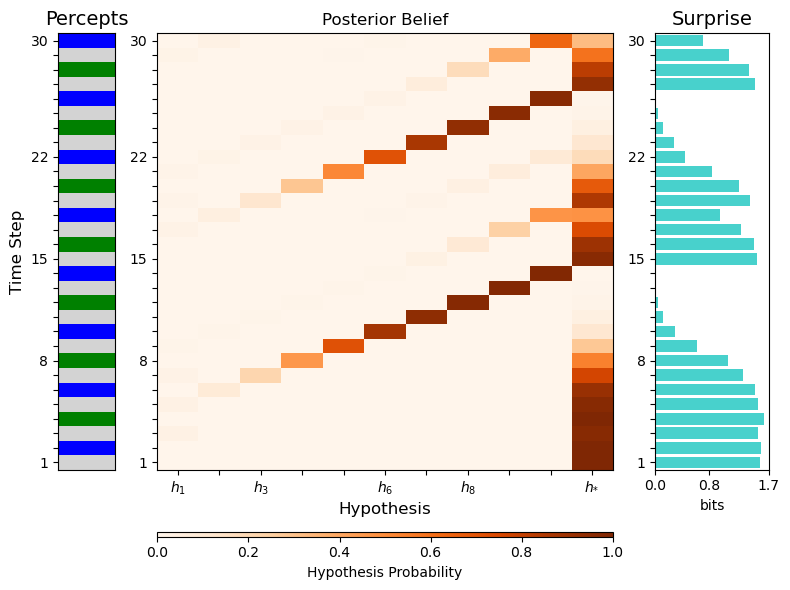

In [511]:
np.random.seed(1033300925)

#define percepts
off = 0
green = 1
blue = 2
colormap = np.array(['lightgrey', 'green', 'blue']) #for plotting

#define environment
percept_cycle = np.array([green,off,blue,off]) #light off, light green, light off, light blue
simple_light_cycle = Cyclic_Env(percept_cycle, initial_state = 1) #start with light off to get aliasing


#define agent
category_sizes = [3]
memory_capacity = 10
memory_bias = 0.01
test_sequence_memory = Sequence_Memory(
    category_sizes = category_sizes,
    memory_capacity = memory_capacity,
    memory_bias = memory_bias
)

#prepare simulation
T = 30 #total time to run simulation
test_sequence_memory.prepare_data_storage(data_record = ["all"], record_until = T)

#simulate
percepts = [None] * T
for t in range(T):
    percepts[t] = simple_light_cycle.get_observation()
    test_sequence_memory.sample(percepts[t])
    simple_light_cycle.transition(0) #Use action 0 for no-action environments

#plot memory trace activations over time
memory_filter_performance(test_sequence_memory.data_dic, percepts, colormap)

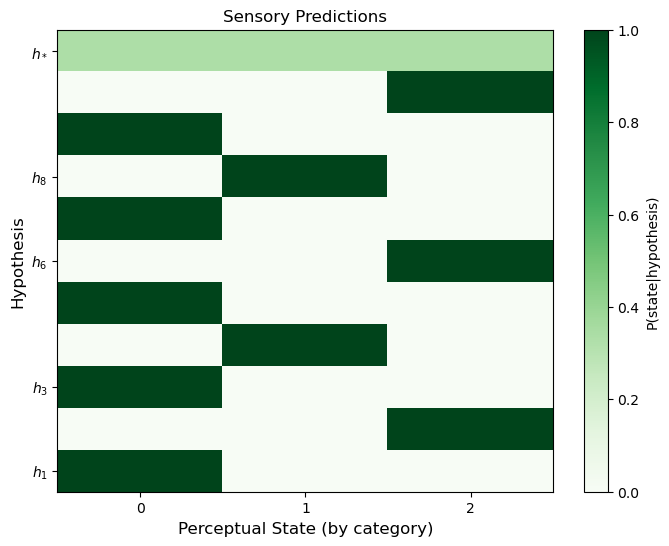

In [512]:
test_sequence_memory.show_sensory_predictions()

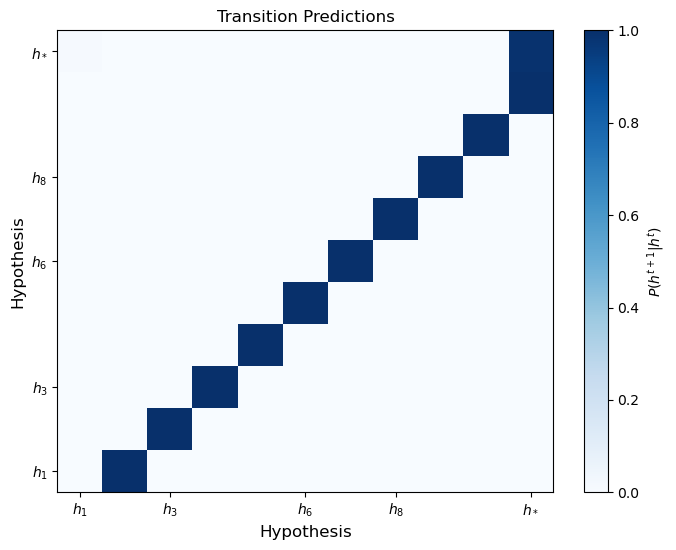

In [513]:
test_sequence_memory.show_transition_predictions()

In [514]:
#| export
from projective_simulation.methods.transforms import decay_toward_stationary

class Short_Term_Memory(Sequence_Memory):
    """
    Short-Term Memory extends Sequence_Memory by introducing memory fading.
    Each encoded memory trace fades toward the stationary sensory predictions at a specified rate.
    Supports different schematic transition methods and capacity overflow behaviors.
    """
    def __init__(
        self,
        category_sizes: list[int],                                  #Number of states each sensor/percept category can take
        memory_capacity: int,                                       #Number of memory nodes.
        memory_bias: float,                                         #Transition probability from non-memory to memory hypothesis.
        fading_rate: float,                                         #Rate parameter for exponential decay toward uniform for memory traces.
        stationary_expectations: NDArray[np.float_] = None,         #Expectation of sensory states in stationarity. Default to uniform distributions for each sensor.
        sensory_predictions: NDArray[np.float_] = None,               #Optional sensory-to-memory weight matrix.
        belief_prior: NDArray[np.float_] = None,                      #Optional 1d array of prior expectations on memories.
        transition_predictions: NDArray[np.float_] = None,            #Optional memory transition matrix.
        next_trace: int = 0,                                         #Starting memory index. 0 indicates no memories encoded.
        data_record: list[str] = [],                                #List of variable names to record each time step. Accepts "all".
        record_until: int = -1,                                     #Number of steps to prepare for data recording. Negative disables recording.
        capacity_overflow_method:str="loop",                        #'loop' or 'stop encoding'.
        stationary_transition_method:str="encoded"                   #'encoded', 'first', or 'learned'.
    ):
        """
        Sets internal variables, initializes default sensory_predictions and transition_predictions if None given, runs structure checks
        """
        super().__init__(
            category_sizes=category_sizes,
            memory_capacity=memory_capacity,
            memory_bias=memory_bias,
            stationary_expectations=stationary_expectations,
            sensory_predictions=sensory_predictions,
            belief_prior=belief_prior,
            transition_predictions=transition_predictions,
            next_trace=next_trace,
            data_record=data_record,
            record_until=record_until,
            capacity_overflow_method=capacity_overflow_method
        )
        self.fading_rate = fading_rate
        self.stationary_transition_method = stationary_transition_method

        if self.stationary_transition_method == "encoded" and transition_predictions is None:
            for i in range(self.memory_capacity, np.shape(self.transition_predictions)[0]): #set non-memory hypothesis transitions
                self.transition_predictions[i, i] = 1 - self.memory_bias
                self.transition_predictions[i, 0] = self.memory_bias #if no memories encoded, bias goes to stationary hypothesis

    def learn(self, 
              percept:NDArray[np.int_]|None = None
              ):
        """
        Fade all memory traces, then update memory with the new percept.
        """        
        super().learn(percept)
        self.fade()
        self.prepare_new_trace()

    def encode_memory(self, percept:NDArray[np.int_]|None=None):
        """
        Encode the percept into memory, updating sensory and transition predictions. If passed none, uses self.percept
        Handles schematic transition methods and capacity overflow.
        """
        super().encode_memory(percept)
        if self.stationary_transition_method == "encoded":
            for i in range(self.memory_capacity, self.num_hypotheses):
                #min function used below because one memory trace always needs to be reserved for next percept
                #the added probability will be removed from the reserved trace in the prepare_next_trace function, keeping the transition probabilities normalized
                self.transition_predictions[i, :self.effective_capacity] = self.memory_bias/np.min([self.effective_capacity, self.memory_capacity - 1]) 
        # if self.stationary_transition_method == "learned":
        #     for i in range(self.memory_capacity,self.num_hypotheses):
        #         #add weight to transition from non-memory hypotheses to current memory hypothesis then renormalize
        #         self.transition_predictions[i, self.last_trace] = self.memory_bias
        #         self.transition_predictions[i,:] = self.transition_predictions[i,:] / np.sum(self.transition_predictions[i,:])


    def fade(self):
        """
        Apply exponential decay toward uniform distribution for each memory trace.
        """
        for i in range(len(self.category_sizes)):
            faded_memories = decay_toward_stationary(
                pmfs = self.sensory_predictions[:self.memory_capacity, self.category_indexer == i],
                gammas = self.fading_rate,
                stationary_distribution = self.sensory_predictions[-1, self.category_indexer == i] #-1 slices predictions of H_*
            )
            self.sensory_predictions[:self.memory_capacity, self.category_indexer == i] = faded_memories

    def prepare_new_trace(self):
        #prepare trace for next time step
        current_trace = self.next_trace
        if self.capacity_overflow_method == "decay_based":
            #get kullback-leibler divergence between each memory trace and stationary hypothesis
            kl_divergences = np.zeros(self.memory_capacity)
            for i in range(self.memory_capacity):
                kl_divergences[i] = np.sum(
                    self.sensory_predictions[i, :] * np.log(
                        self.sensory_predictions[i, :] / self.sensory_predictions[-1, :] #-1 is stationary hypothesis
                    )
                )
            #find memory trace with lowest divergence to stationary hypothesis
            self.next_trace = np.min(np.argmin(kl_divergences)) #in case of ties, take first
        elif self.capacity_overflow_method != "stop encoding":
            #if capacity overflow method is 'learned', this updated is handled by the sequence memory parent class
            self.next_trace = (current_trace + 1) % self.memory_capacity
        
        #prepare transition probabilities to new next trace
        if self.capacity_overflow_method != "stop encoding":
            if self.stationary_transition_method == "encoded":
                self.transition_predictions[-1,self.next_trace] = 0 #removes memory bias added to transition to this trace
            for i in range(self.num_hypotheses):
                p_prepared_trace = self.transition_predictions[i,self.next_trace] #transitions to newly prepared trace will be forgotten by transferring them to h*
                self.transition_predictions[i,-1] = self.transition_predictions[i,-1] + p_prepared_trace
                self.transition_predictions[i,self.next_trace] = 0
                if i == current_trace:
                    self.transition_predictions[i,:] = 0
                    self.transition_predictions[i, self.next_trace] = 1

### Short_Term_Memory Example

Short-Term memory filters can perfrom state estimations in cyclic environments with certain amounts of noise. Here, we simulate short-term memory in an environment that produces a green-off-blue-off cycle, but where the green/blue color signal is subject to error. We then evaluate the belief state dynamics of this network with a function that plots the time evolution of percept, posterior belief state, and suprise side-by-side. Finally, to illustrate how the observation function changes in short-term memory, we visualize the observation function at the end of the cycle. When compared to the sequence memory, this example illustrates how short-term memory can handle certain kinds of noise in an environment.

In [515]:
from projective_simulation.envs.POMDPs import Noisy_Cycle
from projective_simulation.methods.visualization import plot_heatmap
from projective_simulation.methods.visualization import memory_filter_performance

In [ ]:
np.random.seed(1032300925)
#define percepts
green = 0
off = 1
blue = 2
colormap = np.array(['green','lightgrey', 'blue']) #for plotting

#define environment
percepts = np.array([0,1,2])
observation_function = np.array([[0.9,0.,0.1],
                                 [0.,1.,0.],
                                 [0.1,0.,0.9],
                                 [0.,1.,0.]])
noisy_light_cycle = Noisy_Cycle(percepts, observation_function)

#define agent
category_sizes = [3]
memory_capacity = 7
memory_bias = 0.02
fading_rate = 0.1 #this is fast, for the sake of example
test_stm = Short_Term_Memory(
    category_sizes=category_sizes,
    memory_capacity=memory_capacity,
    memory_bias=memory_bias,
    fading_rate=fading_rate,
    stationary_transition_method="encoded",
    capacity_overflow_method="decay_based"
)


#prepare simulation
T = 51 #total time to run simulation
observed_percepts = [None] * T #data structure for storing observations
test_stm.prepare_data_storage(data_record = ["all"], record_until = T)

#simulate for T steps and store observations
for t in range(T):
    percept = noisy_light_cycle.get_observation()
    observed_percepts[t] = percept
    test_stm.sample(percept)  
    noisy_light_cycle.transition(0) #use action 0 for env with no action control

No stationary_expectations given, using uniform distributions for all sensors
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


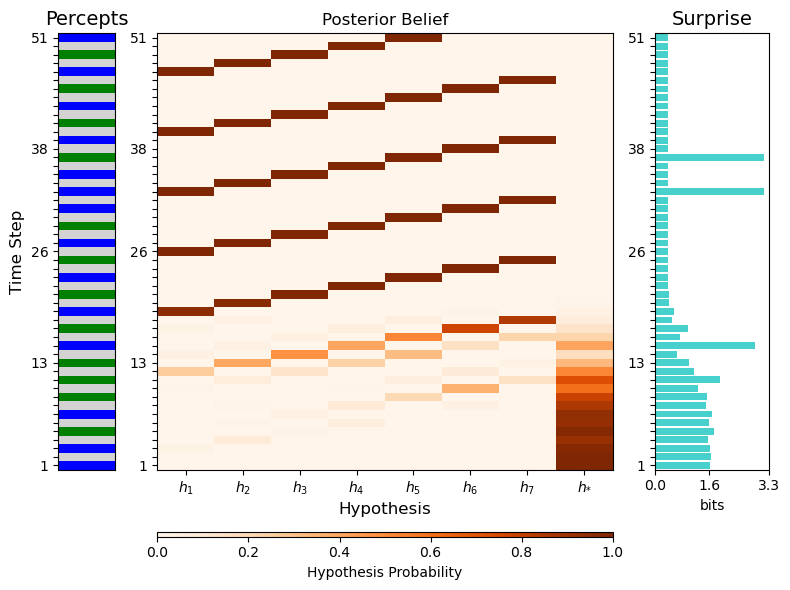

In [517]:
memory_filter_performance(memory_data=test_stm.data_dic, 
                          observed_percepts=observed_percepts, 
                          colormap=colormap)

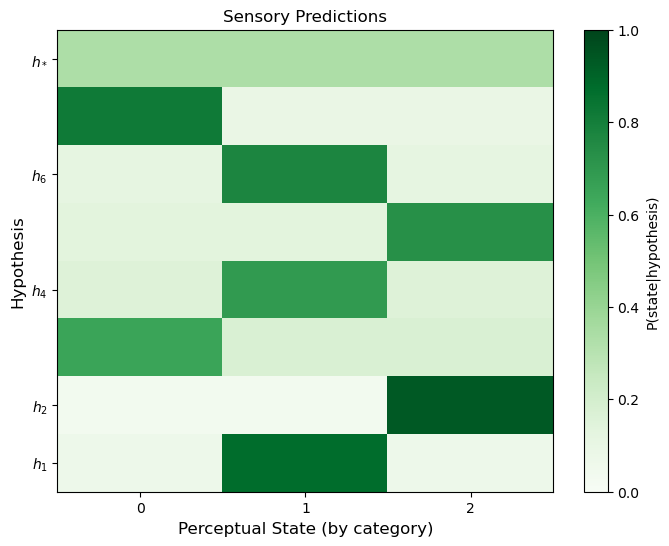

In [518]:
test_stm.show_sensory_predictions()

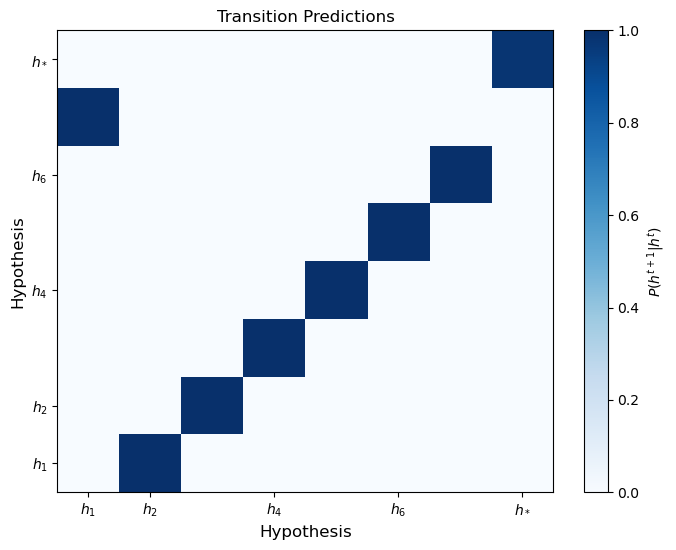

In [549]:
test_stm.show_transition_predictions()

In [520]:
#| export
#| hide
## Fading Rate Encoders for Long-Term Memory
def sigmoid_fading_rate(
        gamma: float,                                   #default fading rate
        sigma: float,                                   #surprise factor
        centers: NDArray[np.float_],                    #array of stationary probabilities for observed states of each sensor
        sensor_state_probabilities: NDArray[np.float_], #array of prior probabilities for observed states of each sensor
        log_base: float = 2.
    )->NDArray[np.float_]:

    assert np.shape(sensor_state_probabilities) == np.shape(centers), "a sigmoid center must be given for each probability for which a fading rate is to be derived"

    if gamma == 0.:
        return np.zeros_like(sensor_state_probabilities)
    if gamma == 1.:
        return np.ones_like(sensor_state_probabilities)
    skew = np.log(gamma/(1-gamma))/np.log(log_base) #sets rate to gamma when logistic component is 0 (i.e. at sigmoid center)
    shift = 2*(sensor_state_probabilities - centers) #centers sigmoid
    scale = -np.log(1-sigma)/np.log(log_base) #slope of sigmoid

    x = skew + scale * shift
    fading_rates = 1/(1 + log_base ** -x)

    return(fading_rates)

def surprise_advantage_fading_rate(
        gamma: float,                                   #default fading rate
        sigma: float,                                   #surprise factor
        category_indexes:NDArray[np.int_], 
        categorical_predictions:NDArray[np.float_], 
        categorical_surprises:NDArray[np.float_], 
        log_base: float = 2.
        )->NDArray[np.float_]:
    sensor_labels, inv = np.unique(category_indexes, return_inverse=True)
    plogp = categorical_predictions * np.log(categorical_predictions)
    prediction_entropies = -np.bincount(inv, weights = plogp, minlength = sensor_labels.size) #sums the plogp for each value in category_indexer and returns as 1d array
    converted_entropies = prediction_entropies/np.log(log_base)
    surprise_gaps = categorical_surprises - converted_entropies
    fading_rates = gamma ** (log_base ** (sigma * surprise_gaps))
    return(fading_rates)

In [521]:
#| export
class Long_Term_Memory(Short_Term_Memory):
    """
    Long_Term_Memory extends Short_Term_Memory by introducing surprise-modulated memory fading and memory stabilization.
    Each encoded memory trace fades toward a given (estimated) stationary distribution at a rate modulated by the surprise of the encoded percept and by reactivation.
    Reactivation slows fading and can reinforce the memory trace, stabilizing early memories of sequences.
    """
    def __init__(
        self,
        category_sizes: list[int],                  #Number of states each sensor/percept category can take
        memory_capacity: int,                       #Number of memory nodes.
        memory_bias: float,                         #Transition probability from non-memory to memory hypothesis.
        fading_rate: float,                         #Base rate parameter for exponential decay toward uniform for memory traces.
        surprise_factor: float = 0.,                #Scales the degree to which surprise slows down memory fading.
        consolidation_rate: float = 0.,             #Scales the degree to which reactivation slows fading.
        stationary_expectations: NDArray[np.float_] = None, #Expectation of sensory states in stationarity. Default to uniform distributions for each sensor.
        sensory_predictions: NDArray[np.float_] = None,     #Optional sensory-to-memory weight matrix.
        belief_prior: NDArray[np.float_] = None,            #Optional 1d array of prior expectations on memories.
        transition_predictions: NDArray[np.float_] = None,  #Optional memory transition matrix.
        next_trace: int = 0,                                 # Starting memory time index. 0 indicates no memories encoded.
        data_record: list[str] = [],                    #List of variable names to record each time step. Accepts "all".
        record_until: int = -1,                         #Number of steps to prepare for data recording. Negative disables recording.
        fading_rate_method:str = "sigmoid",             #Method for computing fading rates ("sigmoid" or "surprise_advantage").
        capacity_overflow_method:str = "stop encoding", #'loop' or 'stop encoding'.
        stationary_transition_method:str = "encoded"     #'encoded', 'first', or 'learned'.
    ):
        """
        Initialize the Long_Term_Memory filter.
        """
        super().__init__(
            category_sizes=category_sizes,
            memory_capacity=memory_capacity,
            memory_bias=memory_bias,
            fading_rate=fading_rate,
            stationary_expectations=stationary_expectations,
            sensory_predictions=sensory_predictions,
            belief_prior=belief_prior,
            transition_predictions=transition_predictions,
            next_trace=next_trace,
            data_record=data_record,
            record_until=record_until,
            capacity_overflow_method=capacity_overflow_method,
            stationary_transition_method=stationary_transition_method
        )
        assert 0 <= surprise_factor <= 1, "surprise_factor must be in [0, 1]"
        self.surprise_factor = surprise_factor
        self.consolidation_rate = consolidation_rate
        self.fading_rate_method = fading_rate_method
        self.memory_fade = np.zeros((np.shape(self.sensory_predictions)[0], len(self.category_sizes)))  # fading rates for all memories

    def learn(
            self, 
            percept: NDArray[np.int_]|None=None):
        """
        Given a percept, update world model and stabilize memories.
        """
        super().learn(percept)
        self.stablize_memories()

    def fade(self):
        """
        Apply exponential decay toward uniform distribution for each memory trace, using memory-specific fading rates.
        """
        for i in range(len(self.category_sizes)):
            faded_memories = decay_toward_stationary(
                pmfs = self.sensory_predictions[:, self.category_indexer == i], #unlike in STM, fading is applied to stationary hypothesis - but rate is set to 0 (and it mixes with itself)
                gammas = self.memory_fade[:, i],
                stationary_distribution = self.sensory_predictions[-1,self.category_indexer == i]
            )
            self.sensory_predictions[:, self.category_indexer == i] = faded_memories

    def stablize_memories(self):
        """
        Reduce fading rate of reactivated memories according to the weight of reactivation (posterior belief).
        """
        for i in range(self.effective_capacity):
            self.memory_fade[i, :] = self.memory_fade[i, :] * (1 - (self.belief_posterior[i] * self.consolidation_rate))

    def encode_memory(
            self, 
            percept: NDArray[np.int_]|None=None):
        """
        Encode the current percept into memory, updating sensory and transition predictions.
        Sets the initial fading rates of each category in the new memory.
        """
        super().encode_memory(percept)
        if not self.effective_capacity == self.memory_capacity or not self.capacity_overflow_method == "stop encoding":
            self.memory_fade[self.next_trace, :] = self.get_fading_rates()


    def get_fading_rates(self):
        """
        Compute the fading rates for the current memory trace using the selected fading_rate_method.
        """
        if self.fading_rate_method == "sigmoid":
            if self.fading_rate in [0., 1.] and self.surprise_factor > 0.:
                print("Warning: fading_rate of 0 or 1 will override the effect of surprise_factor when using sigmoid fading_rate_method")
            fading_rates = sigmoid_fading_rate(
                gamma=self.fading_rate,
                sigma=self.surprise_factor,
                centers = self.sensory_predictions[-1,self.get_one_hot_percept(self.percept)],
                sensor_state_probabilities=self.sensory_expectation[self.get_one_hot_percept(self.percept)],
                log_base=self.log_base
            )
        elif self.fading_rate_method == "surprise_advantage":
            fading_rates = surprise_advantage_fading_rate(
                gamma=self.fading_rate,
                sigma=self.surprise_factor,
                category_indexes=self.category_indexer,
                categorical_predictions=self.sensory_expectation,
                categorical_surprises=self.get_surprise(),
                log_base=self.log_base
            )
        else:
            raise ValueError(f'{self.fading_rate_method} is not a valid fading_rate_method')
        return fading_rates


### Long_Term_Memory Example
When the environment does not tend to repeat percepts in a cycle of fixed length, or sequences are long, short-term memory often fails. Here, we define changes to the memory that introduce Long-Term Memory. The long term memory filter encodes the surprise of each sensory state into a memory trace - higher surprise slows fading and thus increases the probability of reactivation upon a similar state. Reactivation also causes the sensory predictions of the memory to mix with current sensory activations - typically reinforcing the memory and counter-acting fading. Together, these dynamics stablize early memories of sequences. 

Here, we build an environment that alternates between three sequences of different lengths. Each sequence befins with either 'green', 'blue', or 'red'. The color indicates how many time steps of 'off' will occur before the 'black' percept. A new sequence then begins at random. We visualize the final observation function of Long-Term Memory simulated in such an environment show how the Long-Term Memory retains surprising memories. Note, for example, the fading of memories after time-step forty, when a sequence similar to the first one observed by the Long-Term Memory repeats.

In [522]:
from projective_simulation.envs.POMDPs import POMDP
from projective_simulation.methods.visualization import memory_filter_performance
from projective_simulation.methods.visualization import plot_heatmap

In [551]:
np.random.seed(1029300925)
#define percepts
off = 0
green = 1
blue = 2
red = 3
black = 4
colormap = np.array(['lightgrey', 'green', 'blue', 'red', 'black']) #for plotting

#define environment
percepts = np.array([0,1,2,3,4])
#set up environment
observation_function = np.array([(0.,1.,0.,0.,0.),
                                 (0.,0.,0.,0.,1.),
                                 (0.,0.,1.,0.,0.),
                                 (1.,0.,0.,0.,0.),
                                 (0.,0.,0.,0.,1.),
                                 (0.,0.,0.,1.,0.),
                                 (1.,0.,0.,0.,0.),
                                 (1.,0.,0.,0.,0.),
                                 (0.,0.,0.,0.,1.),
                                ])
transition_function = np.array([(0.,1.,0.,0.,0.,0.,0.,0.,0.),
                                (1/3,0.,1/3,0.,0.,1/3,0.,0.,0.),
                                (0.,0.,0.,1.,0.,0.,0.,0.,0.),
                                (0.,0.,0.,0.,1.,0.,0.,0.,0.),
                                (1/3,0.,1/3,0.,0.,1/3,0.,0.,0.),
                                (0.,0.,0.,0.,0.,0.,1.,0.,0.),
                                (0.,0.,0.,0.,0.,0.,0.,1.,0.),
                                (0.,0.,0.,0.,0.,0.,0.,0.,1.),
                                (1/3,0.,1/3,0.,0.,1/3,0.,0.,0.)
                               ])

alternating_cycles = POMDP(percepts = percepts, 
                           observation_function = observation_function, 
                           transition_function = transition_function[:,:,np.newaxis])

#set up memory filter
category_sizes = [5]
memory_capacity = 80
memory_bias = 0.001
fading_rate = 0.01
consolidation_rate = 0.1
surprise_factor = 0.95

#give schematic hypothesis and unencoded memories default sensory predictions equal to stationary expectation
sensory_predictions = np.tile([3/9,1/9,1/9,1/9, 3/9], (memory_capacity + 1, 1))

test_ltm = Long_Term_Memory(category_sizes = category_sizes,
                            memory_capacity = memory_capacity,
                            memory_bias = memory_bias,
                            sensory_predictions = sensory_predictions,
                            fading_rate = fading_rate,
                            consolidation_rate = consolidation_rate, 
                            surprise_factor = surprise_factor,
                            capacity_overflow_method="decay_based"
                           )

#prepare simulation
T = 80 #total time to run simulation
observed_percepts = [None] * T #data structure for storing observations
test_ltm.prepare_data_storage(data_record = ["all"], record_until = T)

#simulate
for t in range(T):
    percept = alternating_cycles.get_observation()
    observed_percepts[t] = percept
    test_ltm.sample(percept)
    alternating_cycles.transition(0) #use action 0 for environments with no action mediation

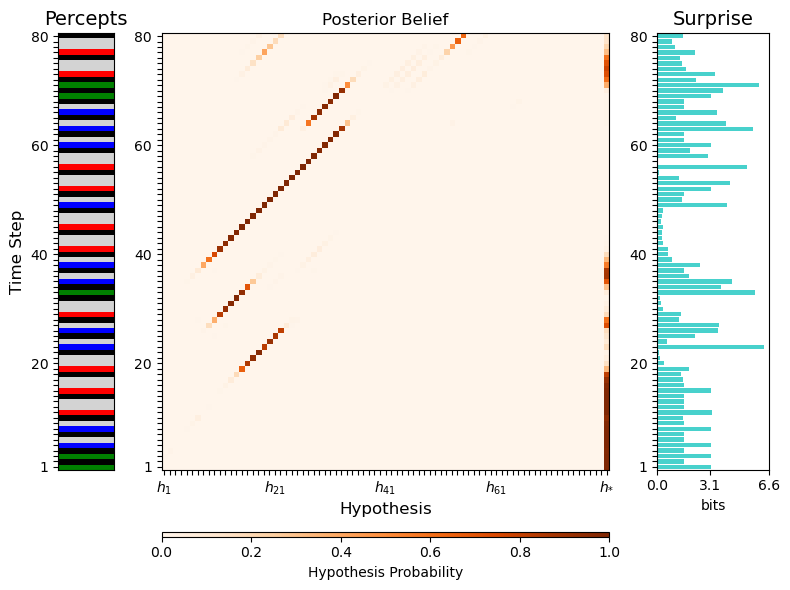

In [552]:
memory_filter_performance(memory_data=test_ltm.data_dic, 
                          observed_percepts=observed_percepts, 
                          colormap=colormap)

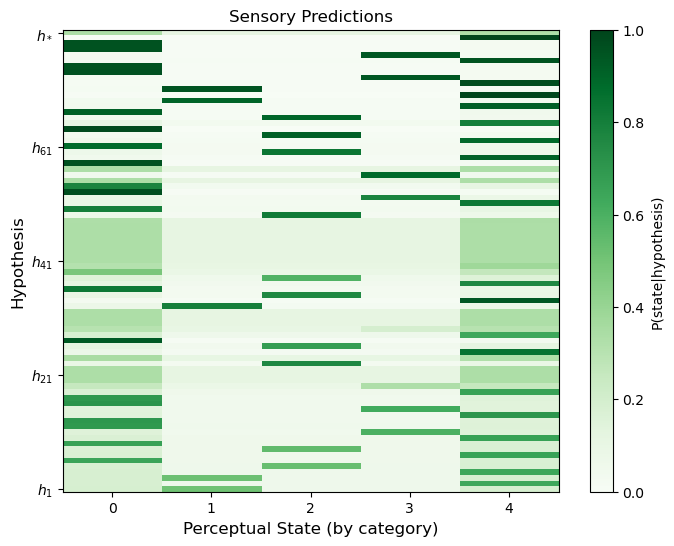

In [553]:
#Plot sensory predictions. Note that the oldest memories tend to be "sharper" then middle-age memories.
test_ltm.show_sensory_predictions()

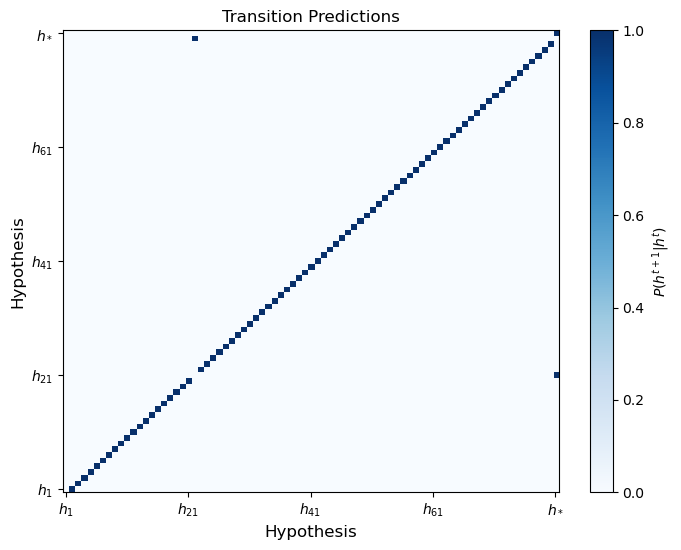

In [554]:
test_ltm.show_transition_predictions()

In [527]:
#| export
class Associative_Memory(Long_Term_Memory):
    """
    Associative_Memory extends Long_Term_Memory by introducing learning and re-encoding mechanisms.
    This class allows memory traces to be updated based on prediction differences (reassociation_rate) and reactivation (reencoding_rate).
    Transition weights between memory traces can be learned, and reactivation can reinforce or generalize memory traces.
    """
    def __init__(
        self,
        category_sizes: list[int],                  #Number of states each sensor/percept category can take
        memory_capacity: int,                       #Number of memory nodes.
        memory_bias: float,                         #Transition probability from non-memory to memory hypothesis.
        fading_rate: float,                         #Base rate parameter for exponential decay toward uniform for memory traces.
        surprise_factor: float = 0.,                #Scales the degree to which surprise slows down memory fading.
        consolidation_rate: float = 0.,             #Scales the degree to which reactivation slows fading.
        reassociation_rate: float = 0.,             #Scales influence of prediction differences on transition weights.
        reencoding_rate: float = 0.,                #Scales the degree to which re-activation of a memory affects its sensory predictions.
        stationary_expectations: NDArray[np.float_] = None,      #Expectation of sensory states in stationarity. Default to uniform distributions for each sensor.
        sensory_predictions: NDArray[np.float_] = None,     #Optional sensory-to-memory weight matrix.
        belief_prior: NDArray[np.float_] = None,            #Optional 1d array of prior expectations on memories.
        transition_predictions: NDArray[np.float_] = None,  #Optional memory transition matrix.
        next_trace: int = 0,                                     #Starting memory time index. 0 indicated no memories encoded
        data_record: list[str] = [],                        #List of variable names to record each time step. Accepts "all".
        record_until: int = -1,                             #Number of steps to prepare for data recording. Negative disables recording.
        fading_rate_method: str = "sigmoid",                #Method for computing fading rates ("sigmoid" or "surprise_advantage").
        capacity_overflow_method: str = "stop encoding",    #'loop' or 'stop encoding'.
        stationary_transition_method: str = "learned"        #'encoded', 'first', or 'learned'.
    ):
        """
        Initialize the Associative_Memory filter.
        """
        if stationary_transition_method == "learned" and transition_predictions is None:
            transition_predictions = Initialize_Memory_Based_Transition_Matrix(
                memory_capacity=memory_capacity,
                memory_bias=memory_bias,
                num_hypotheses=memory_capacity + 1,
                capacity_overflow_method=capacity_overflow_method,
                stationary_transition_method=stationary_transition_method,
            )

        super().__init__(
            category_sizes=category_sizes,
            memory_capacity=memory_capacity,
            memory_bias=memory_bias,
            fading_rate=fading_rate,
            surprise_factor=surprise_factor,
            stationary_expectations=stationary_expectations,
            sensory_predictions=sensory_predictions,
            consolidation_rate=consolidation_rate,
            belief_prior=belief_prior,
            transition_predictions=transition_predictions,
            next_trace=next_trace,
            data_record=data_record,
            record_until=record_until,
            fading_rate_method=fading_rate_method,
            capacity_overflow_method=capacity_overflow_method,
            stationary_transition_method=stationary_transition_method
        )
        self.reassociation_rate = reassociation_rate
        self.reencoding_rate = reencoding_rate
        self.presynaptic_activations = np.zeros_like(self.transition_predictions)  # initialize

    def sample(
            self, 
            percept:NDArray[np.int_]):
        """
        Given a percept; update belief state, update world model, predict next sensor states.
        Store last posterior and presynaptic activations for learning step.
        """
        #retain last posterior and presynaptic activations for learning step
        self.last_posterior = self.belief_posterior.copy()
        self.presynaptic_activations = self.last_posterior[:, np.newaxis] * self.transition_predictions
        sensory_expectation = super().sample(percept)
        return sensory_expectation

    def learn(
            self, 
            percept:NDArray[np.int_]|None=None):
        """
        Given a percept, update world model per LTM, plus re-encode memories and update transitions.
        """
        self.reencode_memories()
        self.update_transitions() 
        super().learn(percept)
     

    def reencode_memories(self):
        """
        Re-encode memory traces by mixing old encoding with new encoding according to reactivation strength.
        """
        categorical_encoding = self.get_one_hot_percept(self.percept).astype(float)
        for i in range(self.effective_capacity):
            reencoding_strength = self.reencoding_rate * self.belief_posterior[i]
            reencoded_memory = reencoding_strength * categorical_encoding + (1 - reencoding_strength) * self.sensory_predictions[i, :]
            self.sensory_predictions[i, :] = reencoded_memory

    def update_transitions(self):
        """
        Update transition weights between memory traces based on prediction differences and learning factor.
        """
        weighted_synapse_differences = self.reassociation_rate * (np.outer(self.last_posterior, self.belief_posterior) - self.presynaptic_activations)
        if self.stationary_transition_method == "learned":
            self.transition_predictions = self.transition_predictions + weighted_synapse_differences
        elif self.reassociation_rate > 0:
            print("Warning: Transition updates ignored because stationary_transition_method is not 'learned'.")

### Associative_Memory Example

Here, we simulate Associative Memory in an environment that alternates between three sequences of different lengths. Each sequence befins with either 'green', 'blue', or 'red'. The color indicates how many time steps of 'off' will occur before the 'black' percept. A new sequence then begins at random. We visualize the time evolution of the belief state of Associative memory side-by-side with the percept sequence and according surprise of the Associative Memory. Then we visualize the final observation function and a portion of the final transition function of the Associative Memory. When compared to the Long-Term Memory, this example illustrates how associative memory uses the plasticity of memory traces to learn about stochastic transitions in the environment, leading memory traces of later experiences where it already understands the environment to fade.

In [528]:
from projective_simulation.envs.POMDPs import POMDP
from projective_simulation.methods.visualization import memory_filter_performance
from projective_simulation.methods.visualization import plot_heatmap

In [607]:
np.random.seed(1035300925)
#define percepts
off = 0
green = 1
blue = 2
red = 3
black = 4

#define environment
percepts = np.array([0,1,2,3,4])
#set up environment
observation_function = np.array([(0.,1.,0.,0.,0.),
                                 (0.,0.,0.,0.,1.),
                                 (0.,0.,1.,0.,0.),
                                 (1.,0.,0.,0.,0.),
                                 (0.,0.,0.,0.,1.),
                                 (0.,0.,0.,1.,0.),
                                 (1.,0.,0.,0.,0.),
                                 (1.,0.,0.,0.,0.),
                                 (0.,0.,0.,0.,1.),
                                ])
transition_function = np.array([(0.,1.,0.,0.,0.,0.,0.,0.,0.),
                                (1/3,0.,1/3,0.,0.,1/3,0.,0.,0.),
                                (0.,0.,0.,1.,0.,0.,0.,0.,0.),
                                (0.,0.,0.,0.,1.,0.,0.,0.,0.),
                                (1/3,0.,1/3,0.,0.,1/3,0.,0.,0.),
                                (0.,0.,0.,0.,0.,0.,1.,0.,0.),
                                (0.,0.,0.,0.,0.,0.,0.,1.,0.),
                                (0.,0.,0.,0.,0.,0.,0.,0.,1.),
                                (1/3,0.,1/3,0.,0.,1/3,0.,0.,0.)
                               ])

alternating_cycles = POMDP(percepts = percepts, 
                           observation_function = observation_function, 
                           transition_function = transition_function[:,:,np.newaxis])

#set up memory filter
category_sizes = [5]
memory_capacity = 100
memory_bias = 0.00001
fading_rate = 0.004
consolidation_rate = 0.2
surprise_factor = 0.97
reencoding_rate = 0.05
reassociation_rate = 0.15

#give schematic hypothesis and unencoded memories default sensory predictions equal to stationary expectation
sensory_predictions = np.tile([3/9,1/9,1/9,1/9, 3/9], (memory_capacity + 1, 1))

test_am = Associative_Memory(category_sizes = category_sizes,
                          memory_capacity = memory_capacity,
                          memory_bias = memory_bias,
                          sensory_predictions = sensory_predictions,
                          fading_rate = fading_rate,
                          consolidation_rate = consolidation_rate,
                          reencoding_rate = reencoding_rate,
                          surprise_factor = surprise_factor,
                          reassociation_rate = reassociation_rate,
                          capacity_overflow_method="decay_based"
                         )

#prepare simulation
T = 1000 #total time to run simulation
observed_percepts = ["None"] * T #data structure for storing observations
test_am.prepare_data_storage(data_record = ["all"], record_until = T)

#simulate
for t in range(T):
    percept = alternating_cycles.get_observation()
    observed_percepts[t] = percept
    test_am.sample(percept)
    alternating_cycles.transition(0) #use action 0 for environments with no action mediation

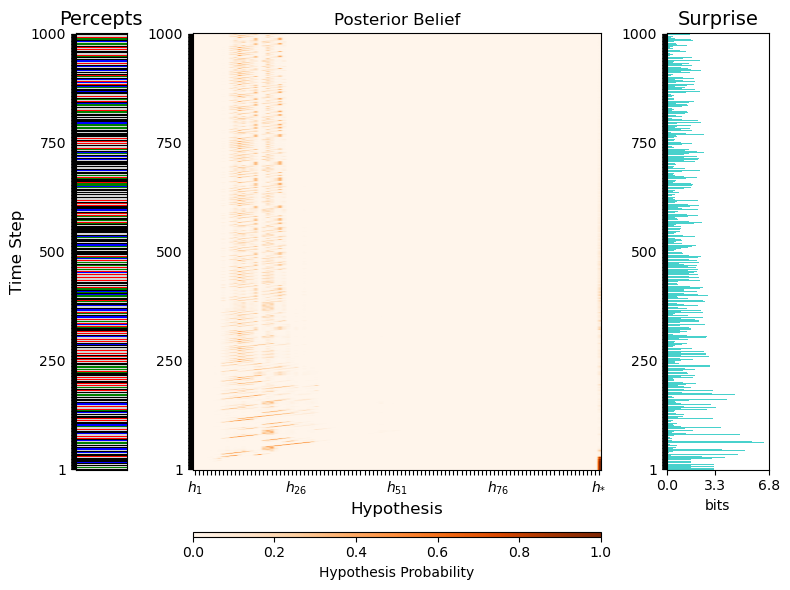

In [608]:
memory_filter_performance(memory_data=test_am.data_dic, 
                          observed_percepts=observed_percepts, 
                          colormap=colormap)

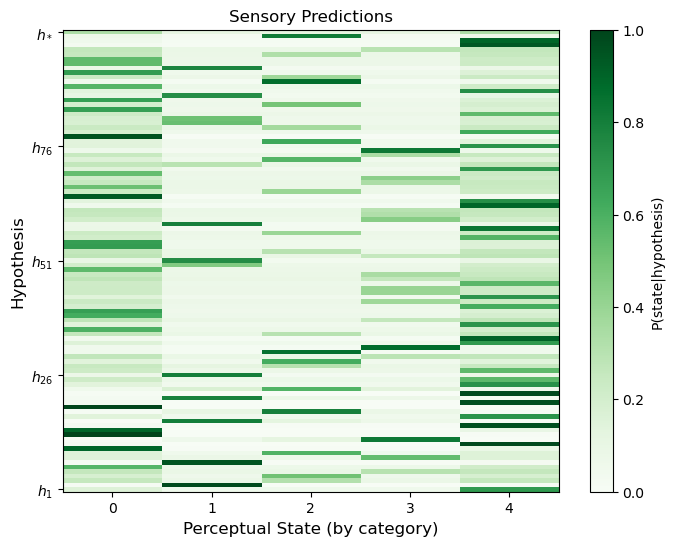

In [609]:
#Plot sensory predictions. Note that the oldest memories tend to be "sharper" then middle-age memories.
test_am.show_sensory_predictions()

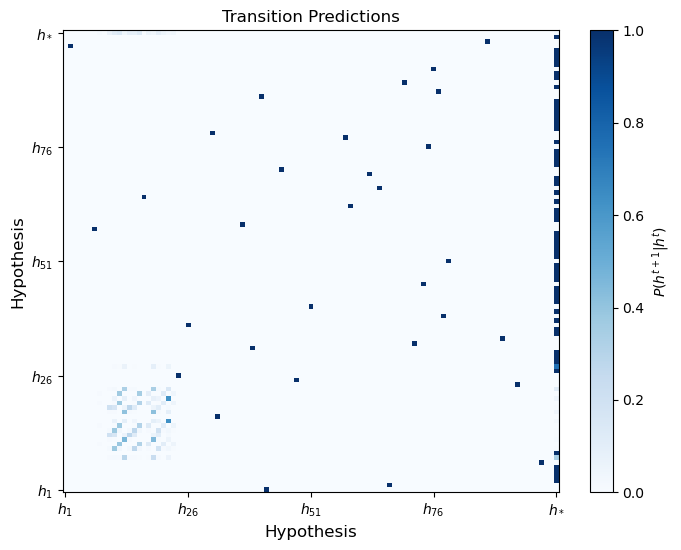

In [610]:
#Plot transition predictions
test_am.show_transition_predictions()

In [533]:
test_am.belief_posterior

array([4.47051214e-009, 4.22682653e-007, 2.95434249e-006, 1.55077703e-003,
       5.67612213e-005, 1.18040243e-004, 4.47325504e-003, 8.54708120e-005,
       9.13485924e-002, 4.38097322e-003, 1.03949624e-004, 4.82774867e-005,
       1.53684320e-001, 2.15955413e-003, 1.47644504e-004, 4.96503150e-005,
       5.67190699e-003, 4.08146056e-005, 2.73637448e-001, 8.08065380e-005,
       6.47722376e-005, 6.77890164e-003, 4.31760746e-005, 2.32270415e-001,
       7.73310961e-005, 1.92829517e-004, 7.58555695e-003, 5.78239460e-005,
       1.80819424e-001, 7.42636036e-005, 1.02398719e-003, 2.17595689e-144,
       5.02426158e-190, 2.61222902e-199, 1.54388716e-005, 4.83016016e-167,
       2.55167779e-005, 5.58296984e-201, 7.74373493e-095, 1.60114744e-095,
       5.14289591e-006, 2.68623492e-319, 2.96777502e-006, 4.94083521e-005,
       4.60511151e-192, 4.50578309e-168, 6.04363353e-005, 9.17064392e-152,
       9.82155183e-112, 6.34379873e-006, 2.41572491e-188, 1.62680590e-257,
       4.74762950e-006, 9

#| hide
# nbdev export

In [534]:
#| hide
import nbdev; nbdev.nbdev_export()